ConvNeXt: paper link: https://arxiv.org/pdf/2201.03545

# Problem: 

The global attention design of Vision Transformers (ViTs) results in high computational costs, especially for high-resolution images. This limits their practicality for many real-world applications.

Things like swin transformers have been proposed but are architecturally more complex. 

# Solution:

Using Transformer inspired training strategies, such as using AdamW, advanced data segmentation, extended training

4x4 non-overlapping convolution with stride 4, mimicking the way Transformers split images into patches

The architecture adopts depthwise convolutions, where the number of groups equals the number of channels. This is conceptually similar to the weighted sum in self-attention, which mixes information spatially but not across channels

In this setup, the hidden dimension of the MLP-style layers is four times wider than the input dimension

Increase kernel size to 7x7 to increase the receptive field brought by the convolutional layers.

Replace ResNet style stem cell with a patchify layer implmentated using 4x4 stride 4
convolutional layer

Depthwise Conv - number of groups equals the number of input channels

Inverted bottleneck - hidden dimension is 4 times the input dimension for each MLP block. Reduces whole network FLOPs to 4.6G, due to significant FLOP reduction in the downsampling residual blocks shortcut 1×1 conv layer. 

3x3 conv layers have efficient implementation in most DL frameworks and hardware.

Move up the position of the depthwise conv layer in each MLP block to before the first 1x1 conv layer.

Use single Relu activation in each block. Fewer activiation functions didn't make a significant difference in performance.

Only one BN layer before the conv 1x1 layers.

Use LN instead of BN.

Measure the flops and parameters of the model.

In [8]:
import torch
import os
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset


os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

class ConvNeXtBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expansion_factor):
        super().__init__()
        self.use_skip = (in_channels == out_channels)
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=7, padding=3, groups=in_channels), # groups makes it depth-wise
            #nn.layernom(in_channels), incorrect! 
            nn.GroupNorm(1, in_channels),
            nn.Conv2d(in_channels, in_channels * expansion_factor, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(in_channels * expansion_factor, out_channels, kernel_size=1),
            nn.GroupNorm(1, out_channels)
        )
    
    def forward(self, x):
        output = self.layers(x)
        return output + x if self.use_skip else output

class ConvNeXt(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=4, stride=2),
            nn.GroupNorm(1, 96),

            ConvNeXtBlock(96, 96, 4),
            ConvNeXtBlock(96, 96, 4),
            ConvNeXtBlock(96, 96, 4),

            nn.GroupNorm(1, 96),
            nn.Conv2d(96, 192, kernel_size=2, stride=2),

            ConvNeXtBlock(192, 192, 4),
            ConvNeXtBlock(192, 192, 4),
            ConvNeXtBlock(192, 192, 4),

            nn.GroupNorm(1, 192),
            nn.Conv2d(192, 384, kernel_size=2, stride=2),

            ConvNeXtBlock(384, 384, 4),
            ConvNeXtBlock(384, 384, 4),
            ConvNeXtBlock(384, 384, 4),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        
        self.linear = nn.Linear(384, 100)
    
    def forward(self, x):
        x = self.layers(x)
        x = x.squeeze(-1).squeeze(-1)
        x = self.linear(x)

        return x


In [9]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Mild to avoid over-distortion
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4865, 0.4409], std=[0.2673, 0.2564, 0.2761]),
    transforms.RandomErasing(p=0.5)  # Apply after normalization for consistency
])

test_transform = transforms.Compose([
    transforms.ToTensor(), # Moved ToTensor before Normalize (good practice)
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
])

# Load raw datasets
cifar_train_raw = datasets.CIFAR100(root="./data", train=True, download=True, transform=None)

train_size = int(0.9 * len(cifar_train_raw))  # 48,000

train_indices = list(range(0, train_size))
val_indices = list(range(train_size, len(cifar_train_raw)))

# Create datasets with appropriate transforms
cifar_train = Subset(
    datasets.CIFAR100(root="./data", train=True, transform=train_transform),
    train_indices
)
cifar_val = Subset(
    datasets.CIFAR100(root="./data", train=True, transform=test_transform),
    val_indices
)
# Use original test set (10,000 samples) - close to 10% of 60,000
cifar_test = datasets.CIFAR100(root="./data", train=False, transform=test_transform)

train_loader = DataLoader(
    cifar_train,  # Use directly
    batch_size=1024,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=6
)

val_loader = DataLoader(
    cifar_val,  # Use directly
    batch_size=1024,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=6
)

test_loader = DataLoader(
    cifar_test,
    batch_size=1024,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=6
)

num_classes = 100

model = ConvNeXt().to(device)
model = torch.compile(model)

num_epochs = 40
loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
base_lr = 4e-3

batch_scale = 1024 / 256  # 4x larger batches
scaled_lr = base_lr * batch_scale**0.5  # Square root scaling

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-3,  # Keep this for now, let OneCycleLR handle it
    weight_decay=5e-4,
    
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-3,                # Slightly lower peak LR for stability
    epochs=num_epochs,          # Keep 45 epochs
    steps_per_epoch=len(train_loader),
    pct_start=0.4,              # Increase warmup to 40% (18 epochs)
    anneal_strategy='cos',
    div_factor=12.0,            # Start LR = 5e-3 / 12 = 4.2e-4
    final_div_factor=400.0      # Final LR = 5e-3 / 400 = 1.25e-5
)

best_val_loss = float('inf')
scaler = torch.cuda.amp.GradScaler()

start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()

train_losses = []
val_losses = []
epochs_recorded = []

for epoch in range(num_epochs):
    print(f'Starting Epoch {epoch+1}')
    model.train()

    current_loss = 0.0
    num_batches = 0

    for i, data in enumerate(train_loader):
        inputs, targets = data
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(inputs)
            loss = loss_function(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

        current_loss += loss.item()
        num_batches += 1

        if i % 50 == 0:
            print(f'Batch {i}/{len(train_loader)}, Loss: {loss.item():.4f}')


    avg_train_loss = current_loss / num_batches
    print(f'Epoch {epoch+1} finished')
    print(f'Training - Loss: {avg_train_loss:.4f}')

    if (epoch + 1) % 2 == 0:
        model.eval()
        val_loss = 0.0
        val_batches = 0

        print(f'Epoch {epoch+1} finished')
        print(f'average training loss is {avg_train_loss:.4f}')

        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_targets = val_data
                val_inputs, val_targets = val_inputs.to(device, non_blocking=True), val_targets.to(device, non_blocking=True)  # Convert inputs to FP16

                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    val_outputs = model(val_inputs)
                    val_batch_loss = loss_function(val_outputs, val_targets)

                val_loss += val_batch_loss.item()
                val_batches += 1


        avg_val_loss = val_loss / val_batches

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        epochs_recorded.append(epoch + 1)        

        print(f'Epoch {epoch+1} finished')
        print(f'Training - Loss: {avg_train_loss:.4f}')
        print(f'Validation - Loss: {avg_val_loss:.4f}')

end_event.record()

torch.cuda.synchronize()

total_time_ms = start_event.elapsed_time(end_event=end_event)
total_time_mn = total_time_ms / 1000 / 60
print(f"\nTotal training time: {total_time_mn:.2f} minutes")


Using device: cuda
GPU Memory: 23.7 GB
Files already downloaded and verified
Starting Epoch 1


/tmp/ipykernel_10696/2833758575.py:107: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Batch 0/44, Loss: 4.7913
Epoch 1 finished
Training - Loss: 4.4095
Starting Epoch 2
Batch 0/44, Loss: 4.1953
Epoch 2 finished
Training - Loss: 4.0893
Epoch 2 finished
average training loss is 4.0893
Epoch 2 finished
Training - Loss: 4.0893
Validation - Loss: 3.8784
Starting Epoch 3
Batch 0/44, Loss: 4.0222
Epoch 3 finished
Training - Loss: 3.9072
Starting Epoch 4
Batch 0/44, Loss: 3.8784
Epoch 4 finished
Training - Loss: 3.7657
Epoch 4 finished
average training loss is 3.7657
Epoch 4 finished
Training - Loss: 3.7657
Validation - Loss: 3.5539
Starting Epoch 5
Batch 0/44, Loss: 3.7034
Epoch 5 finished
Training - Loss: 3.6472
Starting Epoch 6
Batch 0/44, Loss: 3.5399
Epoch 6 finished
Training - Loss: 3.5139
Epoch 6 finished
average training loss is 3.5139
Epoch 6 finished
Training - Loss: 3.5139
Validation - Loss: 3.2539
Starting Epoch 7
Batch 0/44, Loss: 3.4843
Epoch 7 finished
Training - Loss: 3.3899
Starting Epoch 8
Batch 0/44, Loss: 3.2526
Epoch 8 finished
Training - Loss: 3.2513
Epoch

In [10]:
def evaluate_test_set(model):
    model.eval()
    correct = 0
    total = 0
    
    print("Starting evaluation...")
    
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            
            # Use autocast for consistency if you trained with it
            outputs = model(images)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f}%')
    return accuracy

print("\n=== Running standard evaluation ===")
standard_accuracy = evaluate_test_set(model)   
print(f'Standard Test Accuracy: {standard_accuracy:.4f} ({standard_accuracy:.2f}%)')


=== Running standard evaluation ===
Starting evaluation...
Accuracy of the network on the test images: 62.49%
Standard Test Accuracy: 62.4900 (62.49%)


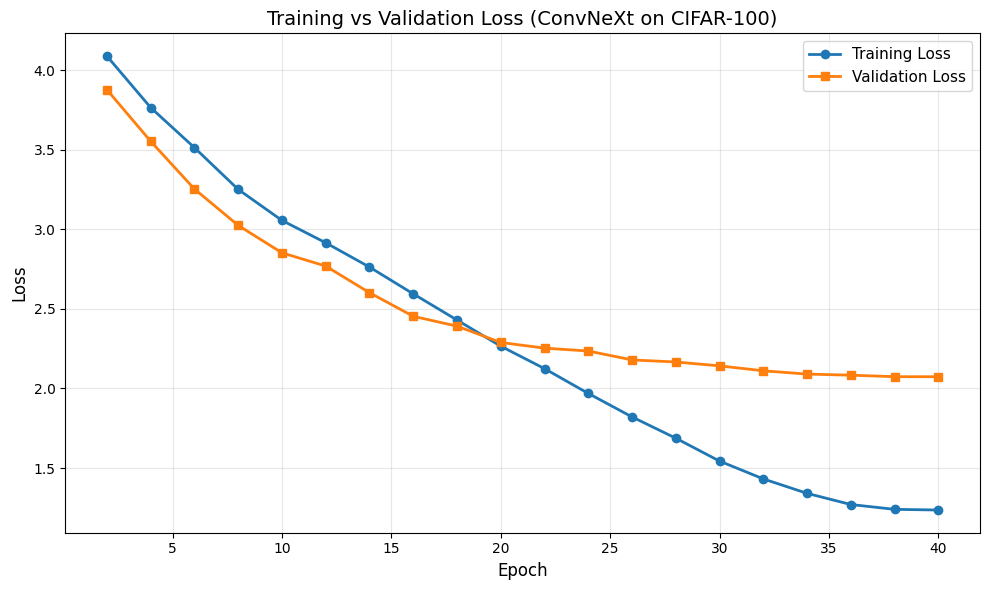


Final training loss: 1.2363
Final validation loss: 2.0740
Gap (val - train): 0.8376
✗ Significant overfitting detected


In [11]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs_recorded, train_losses, label='Training Loss', linewidth=2, marker='o')
plt.plot(epochs_recorded, val_losses, label='Validation Loss', linewidth=2, marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training vs Validation Loss (ConvNeXt on CIFAR-100)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convnext_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Print final gap analysis
final_gap = val_losses[-1] - train_losses[-1]
print(f"\nFinal training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")
print(f"Gap (val - train): {final_gap:.4f}")

if final_gap < 0.1:
    print("✓ Model shows good generalization (small gap)")
elif final_gap < 0.3:
    print("⚠ Mild overfitting detected")
else:
    print("✗ Significant overfitting detected")